In [1]:
import numpy as np
import pandas as pd
import re
import os
import sys
import glob
import matplotlib.pyplot as plt
from astropy.table import Table, join, vstack, hstack
from astropy.io import fits, ascii
import pickle
from PyAstronomy import pyasl
from time import sleep
from tqdm.notebook import tqdm
import warnings
import random
from scipy import stats
import bottleneck as bn
warnings.filterwarnings("ignore")

In [3]:
# plotting parameters
plt.rc('axes', labelsize=12)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='5'
plt.rcParams['ytick.major.pad']='5'

#paper_params = {
#        #'text.usetex' : True,
#        'font.size'   : 10,
#        #'font.family' : 'lmodern',
#        'figure.dpi'  : 200
#        }
#plt.rcParams.update(paper_params)


In [4]:
def split_surf_file(surf_file):
    """
    from file string, extract
    model name,
    metallicity, 
    AGB mass
    inital mass
    final mass
    """
    model_name = surf_file.split('/')[-1][12:]
    metalZ = model_name.split('_')[-1][1:]
    AGB_mass = model_name.split('_')[-2][3:] #(model_name.split('_')[-2][3:4]+'.'+model_name.split('_')[-2][5:6])
    init_mass = (model_name.split('_')[0][1]+'.'+model_name.split('_')[0][3:5])
    final_mass = (model_name.split('_')[1][1]+'.'+model_name.split('_')[1][3:5])
    #if AGB_mass < init_mass: 
    #    return None
    return metalZ,AGB_mass,init_mass,final_mass

In [5]:
list_surf_files = np.genfromtxt('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/list_surface_files_full',dtype=str)
#print(len(list_surf_files))
# generate indicies
split = [split_surf_file(sf) for sf in list_surf_files if split_surf_file(sf) is not None]
# select unique indicies
unique = [list(np.unique(spl)) for spl in np.array(split).T]
print(len(unique[0]),len(unique[1]),len(unique[2]),len(unique[3]))

6 7 65 10


In [6]:
# creat delta list for volume of grid cells....
# this should be a file that is created with the creation of the grid
def create_delta(input_list):
    delta_list = []
    for i in range(len(input_list)-1):
        diff = (float(input_list[i+1]) - float(input_list[i])) / 2
        #print(i, diff)
        delta_list.append(diff)
    delta_list.insert(0,delta_list[0])

    return np.array(delta_list)

In [7]:
# convert unique values to floats to compute distances between grid points
# convert Z values to floats... 0.0001...
metal_Z = []
for z in unique[0]:
    capZ = np.log10(float('0.'+z)/0.0142)
    metal_Z.append(capZ)
metal_Z = np.array(metal_Z)
#metal_Z

# convert agb values to floats... 1p3 = 1.3
agb_masses = []
for m_agb in unique[1]:
    value = float(m_agb[0] + '.' + m_agb[-1])
    agb_masses.append(value)
agb_masses = np.array(agb_masses)
#agb_masses

# convert initial and final masses to floats from the unique array
initial_masses = []
for m_initial in unique[2]:
    value = float(m_initial)
    initial_masses.append(value)
initial_masses = np.array(initial_masses)
#initial_masses

final_masses = []
for m_final in unique[3]:
    value = float(m_final)
    final_masses.append(value)
final_masses = np.array(final_masses)
#final_masses

In [8]:
# create midpoint arrays / delta arrays for the grid...
delta_metal_Z = create_delta(metal_Z)
delta_m_agb = create_delta(agb_masses)
delta_m_init = create_delta(initial_masses)
delta_m_final = create_delta(final_masses)
delta_time = np.ones(30000)

In [9]:
print('Reading MODEL grid from file: "model_grid_full_size.dat" and VALID file "valid_grid_full_size.dat"')

MODEL = np.load('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/model_grid_full_size.dat')
VALID = np.load('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/valid_grid_full_size.dat')
print(np.shape(MODEL),np.shape(VALID))

# generate priors based on size of grid cells -- create own file for this...
Del_Z, Del_magb, Del_mi, Del_mf, Del_t = np.meshgrid(delta_metal_Z,delta_m_agb,delta_m_init,delta_m_final,delta_time, indexing="ij")
# divide by sums for proper priors
top_prod = Del_magb * Del_mi * VALID
THETA = Del_Z/np.sum(Del_Z) * top_prod/(np.sum(top_prod)) * Del_mf/np.sum(Del_mf) * Del_t/np.sum(Del_t) 
print(f'THETA shape: {THETA.shape}')


Reading MODEL grid from file: "model_grid_full_size.dat" and VALID file "valid_grid_full_size.dat"
(6, 7, 65, 10, 30000, 20) (6, 7, 65, 10, 30000)
THETA shape: (6, 7, 65, 10, 30000)


In [10]:

print('Reading in observational data')
# read from the X_Fe_table from abundance infomation
Obs_Data_Table = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/X_Fe_table_3.dat',delimiter='&')
param_mass_table = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/param_mass_table.dat',format='latex')

full_obs_data_table = join(param_mass_table,Obs_Data_Table,keys='stars')
#print(full_obs_data_table)
cristallo_data = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/Cristallo_2016.dat')
goswami_2020_data = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/Gos_Rat_Gos_2020.dat')
goswami_2021_data = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/Gos_Rat_Gos_CEMPs_2021.dat')
DeCastro_Roriz = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/DeCastro_Roriz_Table.dat')
#SAGA_MP = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/SAGA_metalpoor_heavies_APTable.dat')
#SAGA_MR = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/SAGA_metalrich_heavies_APTable.dat')
# stack them all up
#print(len(full_obs_data_table),len(cristallo_data),len(goswami_2020_data),len(goswami_2021_data),len(DeCastro_Roriz))
master_table = vstack([full_obs_data_table,cristallo_data,goswami_2020_data,goswami_2021_data,DeCastro_Roriz],join_type='inner') #SAGA_MP,SAGA_MR
obs_names = np.array(['C','C_sig','FeH','FeH_sig','Sr','Sr_sig','Y','Y_sig','Zr','Zr_sig','Nb','Nb_sig','Mo','Mo_sig','Ru','Ru_sig','Ba','Ba_sig','La','La_sig','Ce','Ce_sig','Pr','Pr_sig','Nd','Nd_sig','Sm','Sm_sig','Eu','Eu_sig','Dy','Dy_sig','Pb','Pb_sig'])
len(master_table)

Reading in observational data


283

In [11]:
def get_star_params(table_in_question, star_index):
    star_name = table_in_question['stars'][star_index]
        
    obs_data = [table_in_question['C'][star_index],   table_in_question['C_sig'][star_index],   # C
                table_in_question['FeH'][star_index], table_in_question['FeH_sig'][star_index], # (Fe)
                table_in_question['Sr'][star_index],  table_in_question['Sr_sig'][star_index],  # Sr
                table_in_question['Y'][star_index],   table_in_question['Y_sig'][star_index],   # Y
                table_in_question['Zr'][star_index],  table_in_question['Zr_sig'][star_index],  # Zr
                table_in_question['Nb'][star_index],  table_in_question['Nb_sig'][star_index],  # Nb
                table_in_question['Mo'][star_index],  table_in_question['Mo_sig'][star_index],  # Mo
                table_in_question['Ru'][star_index],  table_in_question['Ru_sig'][star_index],  # Ru
                table_in_question['Ba'][star_index],  table_in_question['Ba_sig'][star_index],  # Ba
                table_in_question['La'][star_index],  table_in_question['La_sig'][star_index],  # La
                table_in_question['Ce'][star_index],  table_in_question['Ce_sig'][star_index],  # Ce
                table_in_question['Pr'][star_index],  table_in_question['Pr_sig'][star_index],  # Pr
                table_in_question['Nd'][star_index],  table_in_question['Nd_sig'][star_index],  # Nd
                table_in_question['Sm'][star_index],  table_in_question['Sm_sig'][star_index],  # Sm
                table_in_question['Eu'][star_index],  table_in_question['Eu_sig'][star_index],  # Eu
                table_in_question['Dy'][star_index],  table_in_question['Dy_sig'][star_index],  # Dy
                table_in_question['Pb'][star_index],  table_in_question['Pb_sig'][star_index]]  # Pb
    
    # surface parameters
    logg = table_in_question['logg'][star_index]
    e_logg = table_in_question['e_logg'][star_index]
    gstar = 10**logg; e_gstar = 10**(logg-e_logg)
    Teff = table_in_question['Teff'][star_index]
    e_Teff = table_in_question['e_Teff'][star_index]
    log_Teff = np.log10(Teff); log_e_Teff = (e_Teff**2/(Teff*np.log10(e_Teff))**2)**(1/2)
    FeH = table_in_question['FeH'][star_index]
    eFeH = table_in_question['FeH_sig'][star_index]

# -------------------------------
    # add a flag for classification purposes
    flag = 'empty'
    # identify elemental groups for classification purposes
    ls = bn.nanmean([table_in_question['Sr'][star_index],table_in_question['Y'][star_index],
                     table_in_question['Zr'][star_index]])#, table_in_question['Nb'][star_index]
                     #table_in_question['Mo'][star_index]])#,table_in_question['Ru'][star_index]])
    hs = bn.nanmean([table_in_question['Ba'][star_index],table_in_question['La'][star_index],
                     table_in_question['Ce'][star_index],#table_in_question['Pr'][star_index],
                     table_in_question['Nd'][star_index]])    

    C_enhanced = table_in_question['C'][star_index] > 0.50 # or 0.70? # or 0.50?
    Metal_Poor = table_in_question['FeH'][star_index] < -1.00

    dash_s = (hs - table_in_question['Eu'][star_index] > 0.50) and hs > 0.90 ## Beers + Christlieb 2005 / Jorissen 2016
    #dash_s = (hs > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.50) ## Sivarani 2006
    #dash_s = (hs > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.00) and (table_in_question['Eu'][star_index] < 1.00) ## Jonsell 2006
    #dash_s = (hs - table_in_question['Eu'][star_index] > 0.00) and hs > 0.90 ## Abate 2016
    
    dash_rs = (hs - table_in_question['Eu'][star_index] < 0.50) and (hs - table_in_question['Eu'][star_index] > 0.10) ## Beers + Christlieb 2005 / Jorissen 2016
    #dash_rs = (hs > 0.0) and (hs < 0.50) ## Sivarani 2006
    #dash_rs = (table_in_question['Eu'][star_index] > 1.00) and (hs > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.0) ## Abate 2016
    #dash_rs = (table_in_question['Eu'][star_index] > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.0) and (hs - table_in_question['Eu'][star_index] < 1.0) ## Hansen 2019
    
    #dash_r = table_in_question['Eu'][star_index] > 1.00 ## Beers + Christlieb 2005
    dash_r = table_in_question['Eu'][star_index] > 1.00 and hs < 0.0 ## Abate 2016
    
    ## CEMP: [C/Fe] ≥ 0.7
    ## CEMP-r/s: [Ba/Fe] ≥ 1.0, [Eu/Fe] ≥ 1.0
    ## i) 0.0 ≤ [Ba/Eu] ≤ 1.0 and/or 0.0 ≤ [La/Eu] ≤ 0.7;
    ## CEMP-s: [Ba/Fe] ≥ 1.0
    ## i.) [Eu/Fe] < 1.0, [Ba/Eu] > 0.0 and/or [La/Eu] > 0.5;
    ## ii.) [Eu/Fe] ≥ 1.0, [Ba/Eu] > 1.0 and/or [La/Eu] > 0.7.
    
    ## CAMILLA'S CRITERION BASED ON SR AND BA -- LS AND HS
    #CEMP-no [Sr/Ba] > 0.75 New classification
    #if C_enhanced and Metal_Poor and (ls - hs > 0.75): # Hansen 2019
    #    flag = 'CEMP-no'
    #if C_enhanced and Metal_Poor and hs < 0.0: # Beers + Christlieb 2005 / Jorissen 2016
    #    flag = 'CEMP-no'
    ## THE ORDER OF THESE MATTERS
    #if C_enhanced and Metal_Poor and (ls < -1.5): # Hansen 2019
    #    flag = 'CEMP-r'
    #if C_enhanced and Metal_Poor and dash_r: 
    #    flag = 'CEMP-r'
    if C_enhanced and Metal_Poor and (ls - hs > -0.60) and (ls - hs < 0.60): # Hansen 2019
        flag = 'CEMP-s'
    #elif C_enhanced and Metal_Poor and (ls - hs > -1.5) and (ls - hs > -0.5): # Hansen 2019
    #    flag = 'CEMP-r/s'
    elif C_enhanced and Metal_Poor and dash_rs: 
        flag = 'CEMP-r/s'
    elif C_enhanced and Metal_Poor and dash_s: 
        flag = 'CEMP-s'

    ## add flag for CH stars as those at higher metallicities but share same characteristics
    elif Metal_Poor and C_enhanced: # ...? These stars are metal poor, but not SO carbon enriched... this is tough, some could be r/s?
        flag = 'CH'
    
    # Escorza's strong / weak Ba star criterion:
    elif not Metal_Poor and ls > 0.2 or hs > 0.2 and not C_enhanced:
        if ls > 0.8 or hs > 0.8:
            flag = 'SBa'
        elif (ls > 0.2 and ls < 0.8) or (hs > 0.2 and hs < 0.8):
            flag = 'WBa'
# -------------------------------
    ## assign masses based on observations
    ## or from previous population studies
    for col_name in table_in_question.columns:
        if col_name == 'vis':   
            m_star = table_in_question['vis'][star_index]
            e_m_star = table_in_question['e_vis'][star_index]
        # for tagged Barium stars, avg mass is ~2.50
        elif flag == 'WBa' or flag == 'SBa':
            m_star = np.nan # 2.50
            e_m_star = np.nan # 1.00
        # CEMP stars, avg mass is ~0.80
        elif flag == 'CEMP-s' or flag == 'CEMP-r/s' or flag == 'CH':
            m_star = np.nan # 0.80
            e_m_star = np.nan # 1.00
        # if not, give it a nan
        else:
            m_star = np.nan #1.50
            e_m_star = np.nan #1.50
# -------------------------------
    # element names (skip errors in names list)
    obs_names_I_ = obs_names[0:-1:2]
    obs_elems_nums = [6,38,39,40,41,42,44,56,57,58,59,60,62,63,66,82]    
    # observed abundances and errors go into obs_data array
    obs_elems = obs_data[0:-1:2]
    obs_errrs = obs_data[1::2]

    # collect observational data and uncertanties in arrays
    # skip Fe (index 1) in these lists...
    obs_names_II = []
    obs_elems_II = []
    obs_errrs_II = []
    for i in range(len(obs_elems)): 
        if i != 1:
            obs_names_II.append(obs_names_I_[i])
            obs_elems_II.append(obs_elems[i])
            obs_errrs_II.append(obs_errrs[i])
    
    #print('Collect observational data for the star in an array')
    X_obs = np.concatenate([[FeH,log_Teff,logg,m_star],obs_elems_II])
    X_sig = np.concatenate([[eFeH,log_e_Teff,e_logg,e_m_star],obs_errrs_II])
            
    return star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, flag

In [12]:
# apply flags... how many are in each category? - we do have some overlaps...
# total Ba stars should be ~190-something
# CEMP should be around 76 (42 -s and 36 -r/s)
# CH should be around 27
Cs_flgs = []
Cr_flgs = []
Crs_flgs = []
Cno_flgs = []
CH_flgs = []
WBa_flgs = []
SBa_flgs = []
empty_flgs = []
for indx in range(len(master_table)):
    #if indx == 106:
    star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, type_flag = get_star_params(master_table,indx)
    #print(star_name, type_flag)
    if type_flag == 'CEMP-s':
        Cs_flgs.append(type_flag)
    elif type_flag == 'CEMP-r':
        Cr_flgs.append(type_flag)
    elif type_flag == 'CEMP-r/s':
        Crs_flgs.append(type_flag)
    elif type_flag == 'CEMP-no':
        Cno_flgs.append(type_flag)
    elif type_flag == 'CH':
        CH_flgs.append(type_flag)
    elif type_flag == 'WBa':
        WBa_flgs.append(type_flag)
    elif type_flag =='SBa':
        SBa_flgs.append(type_flag)
    elif type_flag == 'empty':
        empty_flgs.append(type_flag)
print(len(Cs_flgs),len(Crs_flgs),len(Cr_flgs),len(Cno_flgs),len(WBa_flgs),len(SBa_flgs),len(CH_flgs),len(empty_flgs))

40 23 0 0 88 105 21 6


In [13]:
def read_parameter_stats(star_name):
    """Read and display parameter statistics from file with error bars"""
    
    stats_dir = '/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/statistics_mass_limit_numba'
    stats_file = os.path.join(stats_dir, f'parameter_stats_{star_name}.txt')
    
    # Initialize dictionaries to store statistics
    stats = {
        'metallicity': {},
        'agb_mass': {},
        'initial_mass': {},
        'final_mass': {}
    }
    
    with open(stats_file, 'r') as f:
        lines = f.readlines()
        
        current_section = None
        reading_probs = False  # Flag to track when we're reading probability distributions
        
        for line in lines:
            line = line.strip()
            if not line or '=====' in line:
                continue
                
            if 'Metallicity' in line:
                current_section = 'metallicity'
                reading_probs = False
                #print(f'\n{line}')
            elif 'AGB Mass' in line:
                current_section = 'agb_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Initial Mass' in line:
                current_section = 'initial_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Final Mass' in line:
                current_section = 'final_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Probability distribution:' in line:
                reading_probs = True
                continue
                
            if not reading_probs:
                if 'Mean:' in line:
                    stats[current_section]['mean'] = float(line.split(':')[1])
                    #print(line)
                elif 'Median:' in line:
                    stats[current_section]['median'] = float(line.split(':')[1])
                    #print(line)
                elif 'confidence' in line:
                    intervals = line.split('[')[1].split(']')[0].split(',')
                    stats[current_section]['conf_lower'] = float(intervals[0])
                    stats[current_section]['conf_upper'] = float(intervals[1])
                    
                    # Calculate uncertainties
                    if 'median' in stats[current_section]:
                        median = stats[current_section]['median']
                        stats[current_section]['err_lower'] = median - float(intervals[0])
                        stats[current_section]['err_upper'] = float(intervals[1]) - median
                        # Calculate median uncertainty as half the confidence interval
                        conf_range = float(intervals[1]) - float(intervals[0])
                        stats[current_section]['median_err'] = conf_range / 2
                    #print(line)
            else:
                # Only process probability distribution lines with valid number pairs
                if ':' in line:
                    try:
                        val, prob = line.split(':')
                        val = float(val)
                        prob = float(prob)
                        
                        if 'prob_dist' not in stats[current_section]:
                            stats[current_section]['prob_dist'] = {'values': [], 'probs': []}
                        stats[current_section]['prob_dist']['values'].append(val)
                        stats[current_section]['prob_dist']['probs'].append(prob)
                    except ValueError:
                        continue
                
    # Calculate standard errors for each parameter
    for param in stats:
        if 'prob_dist' in stats[param]:
            values = np.array(stats[param]['prob_dist']['values'])
            probs = np.array(stats[param]['prob_dist']['probs'])
            mean = stats[param]['mean']
            # Calculate standard error
            variance = np.sum(probs * (values - mean)**2)
            stats[param]['std_err'] = np.sqrt(variance)
    
    return stats

In [14]:
# Group models by probability ranges and show confidence contours
def create_confidence_regions(models, confidences=[0.68, 0.95]):
    """Create confidence regions instead of individual tracks"""
    
    # Extract all track points
    all_logT = []
    all_logg = []
    weights = []
    
    for i, model in enumerate(models):
        valid = VALID[model[0], model[1], model[2], model[3], :]
        track_logT = MODEL[model[0], model[1], model[2], model[3], :, 1][valid]
        track_logg = MODEL[model[0], model[1], model[2], model[3], :, 2][valid]
        
        # Weight by model probability (higher weight for better models)
        weight = 1.0 / (i + 1)  # Simple weighting scheme
        
        all_logT.extend(track_logT)
        all_logg.extend(track_logg)
        weights.extend([weight] * len(track_logT))
    
    return np.array(all_logT), np.array(all_logg), np.array(weights)


In [15]:
def density_contours(m1, m2):
    # Flatten arrays and remove any NaN values
    m1_flat = np.array(m1).flatten()
    m2_flat = np.array(m2).flatten()
    
    # Remove NaN values
    mask = ~(np.isnan(m1_flat) | np.isnan(m2_flat))
    m1_clean = m1_flat[mask]
    m2_clean = m2_flat[mask]
    
    print(f"Data shape: {len(m1_clean)} points")
    
    if len(m1_clean) < 2:
        print("Not enough valid data points for KDE")
        return None, None, None
    
    # Create grid for contour plotting
    x_min, x_max = m1_clean.min() - 0.1, m1_clean.max() + 0.1
    y_min, y_max = m2_clean.min() - 1.0, m2_clean.max() + 1.0

    X, Y = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]

    print('Stacking data correctly...')
    # Stack data as row vectors (each column is a data point)
    values = np.vstack([m1_clean, m2_clean])
    
    print('Generating kernel...')   
    kernel = stats.gaussian_kde(values)
    
    print('Generating density contours...')
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions), X.shape)
    
    # mask zero values in Z to avoid plotting issues
    Z = np.ma.masked_where(Z == 0, Z)
    
    return X, Y, Z


In [16]:
def density_contours2(m1, m2):
    # Flatten arrays and remove any NaN values
    m1_flat = np.array(m1).flatten()
    m2_flat = np.array(m2).flatten()
    
    # Remove NaN values
    mask = ~(np.isnan(m1_flat) | np.isnan(m2_flat))
    m1_clean = m1_flat[mask]
    m2_clean = m2_flat[mask]
    
    print(f"Data shape: {len(m1_clean)} points")
    
    if len(m1_clean) < 2:
        print("Not enough valid data points for KDE")
        return None, None, None, None
    
    # Create grid for contour plotting
    x_min, x_max = m1_clean.min() - 0.1, m1_clean.max() + 0.1
    y_min, y_max = m2_clean.min() - 1.0, m2_clean.max() + 1.0

    X, Y = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]

    print('Stacking data correctly...')
    # Stack data as row vectors (each column is a data point)
    values = np.vstack([m1_clean, m2_clean])
    
    print('Generating kernel...')   
    kernel = stats.gaussian_kde(values)
    
    print('Generating density contours...')
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions), X.shape)
    
    # mask zero values in Z to avoid plotting issues
    Z = np.ma.masked_where(Z == 0, Z)
    
    # Calculate sigma contour levels
    # For 2D Gaussian, the fractions of probability mass within each sigma are:
    # 1σ: 39.3%, 2σ: 86.5%, 3σ: 98.9%
    # To find density levels, sample from KDE and use percentiles
    print('Calculating sigma contour levels...')
    samples = kernel.resample(size=10000)  # Generate samples from the KDE
    sample_densities = kernel(samples)  # Evaluate kernel at sample points
    
    # Find density thresholds: percentiles correspond to fractions inside
    # For 39.3% inside 1σ, we want the density where 39.3% of samples have higher density
    sigma1_level = np.percentile(sample_densities, 100 - 39.3)  # 60.7th percentile
    sigma2_level = np.percentile(sample_densities, 100 - 86.5)  # 13.5th percentile
    sigma3_level = np.percentile(sample_densities, 100 - 98.9)  # 1.1th percentile
    
    # Sort in increasing order for matplotlib contour (lowest density = 3σ, highest = 1σ)
    sigma_levels = sorted([sigma1_level, sigma2_level, sigma3_level])
    
    print(f"Sigma contour levels (sorted): 3σ={sigma_levels[0]:.6f}, 2σ={sigma_levels[1]:.6f}, 1σ={sigma_levels[2]:.6f}")
    
    return X, Y, Z, sigma_levels

In [17]:
import cmasher as cmr
sub_greys = cmr.get_sub_cmap("Greys",0.40,0.70)

In [18]:
np.where(master_table['FeH'] < -2.00)[0]

array([ 33,  35,  37,  39,  40,  41,  42,  44,  46,  47,  50,  52,  54,
        56,  57,  58,  59,  60,  61,  63,  64,  65,  66,  67,  70,  71,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  97,  98,  99, 100, 101, 102, 103, 105,
       106, 107, 109, 110, 111, 112, 113, 114, 115, 116])

In [19]:
#star_indx = random.choice(np.arange(len(master_table)))
#star_indx = np.where(master_table['stars'] == 'HD31487')[0][0]
star_indx = 10

star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, type_flag = get_star_params(master_table,star_indx)

print(star_name,type_flag)

if type_flag == 'SBa':
    prob_color = 'Blue'
elif type_flag == 'WBa':
    prob_color = 'cornflowerblue'
elif 'CEMP' in type_flag:
    prob_color = 'crimson'
elif type_flag == 'CH':
    prob_color = 'darkorange'

#print(f'[Fe/H] = {X_obs[0]}, \nTeff = {np.int32(10**X_obs[1])}, \nlogg = {X_obs[2]}, \nMass = {X_obs[3]}')
#print(obs_names_II)
#print(X_obs[4:])

models = np.genfromtxt('models_full_numba_FULL_GRID/best_tracks_and_models_'+ star_name +'_numba.dat',dtype=int)

PVUMa WBa


Data shape: 500 points
Stacking data correctly...
Generating kernel...
Generating density contours...
Calculating sigma contour levels...
Sigma contour levels (sorted): 3σ=22.931013, 2σ=216.666182, 1σ=923.816941


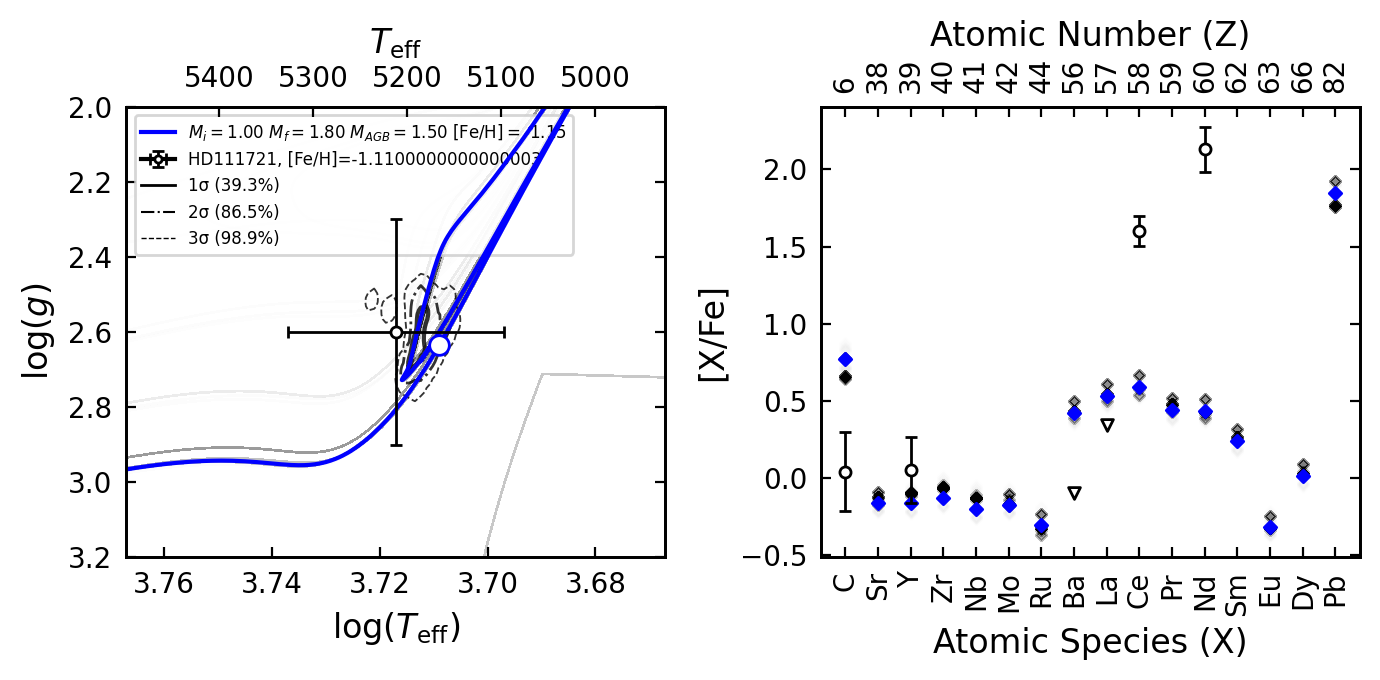

In [29]:
#print('Plotting best models')

# display best models from run of: numba
#best_models = np.load('models_full_mass_limit_weights_stats/best_models_'+star_name+'_mass_limit_weights_stats.dat') 
#best_chis = np.load('chis_full_mass_limit_weights_stats/best_chis_'+star_name+'_mass_limit_weights_stats.dat') 

# determine the number of models to plot (based on probability threshold?)
if len(models) > 500:
    num_mods_to_plot = 500
else:
    num_mods_to_plot = int(len(models))

# create color array for plotting, gradient from color map
mod_colors = plt.cm.Greys(np.linspace(0,40.70,num_mods_to_plot))
mod_alphas = np.logspace(-1,-0.5,num_mods_to_plot)
#mod_sizes = np.linspace(8,32,len(best_models))
#
fig, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(7,3.5),dpi=200)

list_mod_logT = []
list_mod_logg = []

for i,mod_alpha,mod_color in zip(np.arange(0,num_mods_to_plot),mod_alphas,mod_colors):
    #print(i)
    #if i > 0:
    #    i = i*10 # offset to skip the very best models
    #chi_sq = str(round(chi,2)); #print(chi_sq)
    #probab = str(round((prob),2)); #print(probab)

# find name of model track using unique and best model indices
    mod_metal = str(round(np.log10(float(str('0.'+unique[0][models[i][0]]))/0.0142),2))
    mod_AGB = str(unique[1][models[i][1]].split('p')[0]+'.'+unique[1][models[i][1]].split('p')[1]+'0')
    mod_m_i = str(unique[2][models[i][2]])
    mod_m_f = str(unique[3][models[i][3]])

    #track_name = str('[Fe/H]=' + mod_metal + r' M$_{AGB}$=' + mod_AGB + r' M$_i$=' + mod_m_i + r' M$_f$=' + mod_m_f)
    track_name = str(r'$M_i=$' + mod_m_i + r' $M_f=$' + mod_m_f + r' $M_{AGB}=$' + mod_AGB + r' $\mathrm{[Fe/H]}=$' + mod_metal) #+ ' chi2=' + chi_sq + ' log(P)=' + probab)

    # find best model point, extract logT, logg, and abundances
    mod_logT = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],1][-1]
    mod_logg = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],2][-1]
    list_mod_logT.append(mod_logT)
    list_mod_logg.append(mod_logg)
    mod_abunds = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i][4]][4:]

    # find whole track
    valid = VALID[models[i][0],models[i][1],models[i][2],models[i][3],:]
    mod_logT_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,1][valid]
    mod_logg_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,2][valid]
    
    # plot only model with best probability in prob_color
    if i == 0:
        # plot the whole model track, data points, and best model points along the track
        ax1.plot(mod_logT_track,mod_logg_track,zorder=6,color=prob_color,label=track_name, rasterized=True, lw=1.5, alpha=1)
        ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=prob_color,s=50,zorder=7,alpha=1, rasterized=True)
        # plot model abundances
        ax2.scatter(obs_names_II, mod_abunds,zorder=6,marker='D',c=prob_color,s=10,alpha=1,rasterized=True,label=track_name)
    # plot other models in shades of grey
    else:
        # plot the whole model track, data points, and best model points along the track
        ax1.plot(mod_logT_track,mod_logg_track,zorder=0,color=mod_color, rasterized=True, lw=1.0, alpha=mod_alpha/90)
        #ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=mod_color,s=20,zorder=1,alpha=mod_alpha, rasterized=True)
        # plot model abundances
        ax2.scatter(obs_names_II, mod_abunds,zorder=1,marker='D',c=mod_color,s=8,alpha=mod_alpha/60,rasterized=True)

# plot observational data:
#  T_eff, logg on kiel diagram
ax1.errorbar(X_obs[1],X_obs[2], xerr=X_sig[1], yerr=X_sig[2], marker='o',capsize=2, elinewidth=1,
             markersize=4, color='black', markeredgecolor='black', markerfacecolor='white', zorder=10, label=star_name + ', [Fe/H]=' + str(X_obs[0]))
#  observational abundances
for name,elem,err in zip(obs_names_II,obs_elems_II,obs_errrs_II):
    if (not name) or np.isnan(elem):
        continue
    if np.isnan(err):
        ax2.scatter([name],[elem],marker='v',s=18,edgecolor='black',facecolor='white',zorder=10)
    else:
        ax2.errorbar([name],[elem],yerr=[err],ls='',marker='o',markersize=4,elinewidth=1,capsize=2,
                     color='black',markeredgecolor='black',markerfacecolor='white',zorder=10)

#X_con, Y_con, Z_con = density_contours(np.array(list_mod_logT), np.array(list_mod_logg))
#ax1.contour(X_con, Y_con, Z_con, cmap=sub_greys, rasterized=True, 
#            alpha=1.0, linewidths=1.0, levels=5, zorder=5, label='Model Density Contours')

X_con, Y_con, Z_con, sigma_levels = density_contours2(np.array(list_mod_logT), 
                                                       np.array(list_mod_logg))

# Plot with different colors for each sigma level
ax1.contour(X_con, Y_con, Z_con, levels=sigma_levels, 
           colors=['black', 'black', 'black'], linestyles=['dashed', 'dashdot', 'solid'], rasterized=True, alpha=0.8, zorder=4,
               linewidths=[0.66, 1.0, 1.5])

# Create custom legend entries for sigma contours
from matplotlib.lines import Line2D
sigma_legend_elements = [
    Line2D([0], [0], color='black', lw=1.0, linestyle='solid', label='1σ (39.3%)'),
    Line2D([0], [0], color='black', lw=0.75, linestyle='dashdot', label='2σ (86.5%)'),
    Line2D([0], [0], color='black', lw=0.5, linestyle='dashed', label='3σ (98.9%)')
]

ax1.set_xlabel(r'$\log(T_{\mathrm{eff}})$')
ax1.set_ylabel(r'$\log(g)$')
ax1.invert_xaxis()
ax1.invert_yaxis()
ax1.set_xlim(X_obs[1]+0.05,X_obs[1]-0.05)
ax1.set_ylim(X_obs[2]+0.6,X_obs[2]-0.6)

# plot legend on top of all data so it can be read (combine model track and sigma contours)
handles, labels = ax1.get_legend_handles_labels()
handles.extend(sigma_legend_elements)
labels.extend([line.get_label() for line in sigma_legend_elements])
ax1.legend(handles=handles, labels=labels, fontsize=6, loc=2, markerscale=0.65)

# option to include K temperatures
ax4 = ax1.twiny()
ax4.scatter(10**X_obs[1],X_obs[2],s=0)
ax4.set_xlabel(r'$T_{\mathrm{eff}}$')
ax4.invert_xaxis()

ax2.set_xlabel('Atomic Species (X)')
ax2.tick_params(axis='x', rotation=90)
ax2.set_ylabel('[X/Fe]')
#ax2.set_ylim(np.nanmin(X_obs[4:])-0.25,np.nanmax(X_obs[4:])+0.50)

# option to add atomic numbers on axis corresponding to element
ax3 = ax2.twiny()
ax3.set_xlim(ax2.get_xlim())
ax3.set_xticks(range(0,len(obs_names_II)))
ax3.set_xticklabels(obs_elems_nums)
ax3.tick_params(axis='x', rotation=90)
ax3.set_xlabel('Atomic Number (Z)')

plt.tight_layout()
#plt.savefig(star_name+'_numba_contours.png',dpi=200,bbox_inches=None)
#print('End of Line')

Data shape: 500 points
Stacking data correctly...
Generating kernel...
Generating density contours...


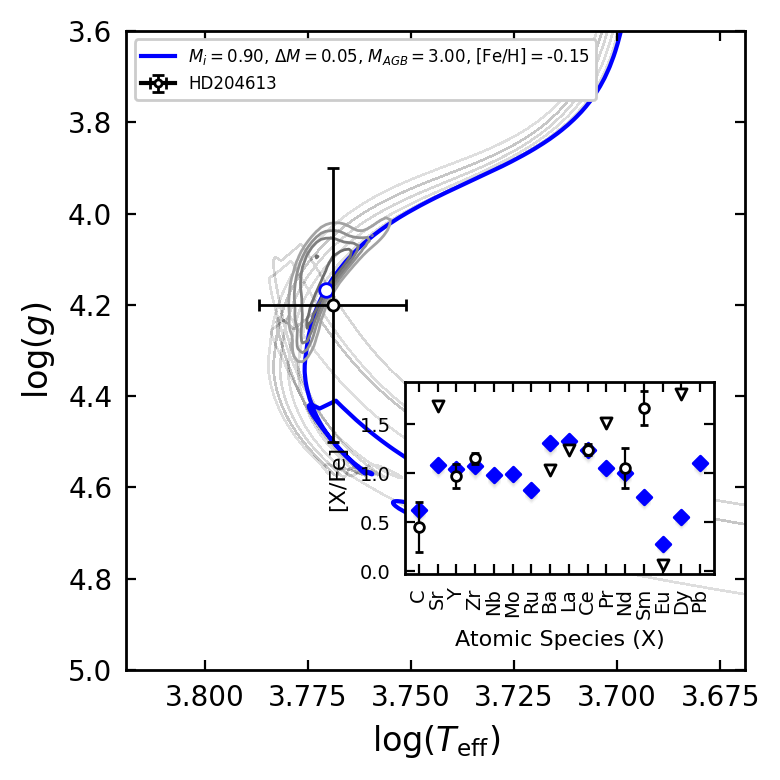

In [25]:
## make the same plot, but make the right panel an inset within the left panel

from matplotlib import patches


fig, ax1 = plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=200)

# create inset axes for abundances
ax2 = ax1.inset_axes([0.45,0.15,0.50,0.30]) # x0, y0, width, height (range 0 to 1)
# shrink axes labels and ticks
ax2.tick_params(axis='both', which='major', labelsize=7)
ax2.tick_params(axis='x', rotation=90)

list_mod_logT = []
list_mod_logg = []

for i,mod_alpha,mod_color in zip(np.arange(0,num_mods_to_plot),mod_alphas,mod_colors):

# find name of model track using unique and best model indices
    mod_metal = str(round(np.log10(float(str('0.'+unique[0][models[i][0]]))/0.0142),2))
    mod_AGB = str(unique[1][models[i][1]].split('p')[0]+'.'+unique[1][models[i][1]].split('p')[1]+'0')
    mod_m_i = str(unique[2][models[i][2]])
    mod_m_f = str(unique[3][models[i][3]])
    delta_m = str(round(float(mod_m_f)-float(mod_m_i),2))

    #track_name = str('[Fe/H]=' + mod_metal + r' M$_{AGB}$=' + mod_AGB + r' M$_i$=' + mod_m_i + r' M$_f$=' + mod_m_f)
    #track_name = str(r'$M_i=$' + mod_m_i + r' $M_f=$' + mod_m_f + r' $M_{AGB}=$' + mod_AGB + r' $\mathrm{[Fe/H]}=$' + mod_metal) #+ ' chi2=' + chi_sq + ' log(P)=' + probab)
    track_name = str(r'$M_i=$' + mod_m_i + r', $\Delta M=$' + delta_m + r', $M_{AGB}=$' + mod_AGB + r', $\mathrm{[Fe/H]}=$' + mod_metal) #+ ' chi2=' + chi_sq + ' log(P)=' + probab)
    
    # find best model point, extract logT, logg, and abundances
    mod_logT = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],1][-1]
    mod_logg = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],2][-1]
    list_mod_logT.append(mod_logT)
    list_mod_logg.append(mod_logg)
    mod_abunds = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i][4]][4:]

    # find whole track
    valid = VALID[models[i][0],models[i][1],models[i][2],models[i][3],:]
    mod_logT_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,1][valid]
    mod_logg_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,2][valid]
    
    # plot only model with best probability in prob_color
    if i == 0:
        # plot the whole model track, data points, and best model points along the track
        ax1.plot(mod_logT_track,mod_logg_track,zorder=1,color=prob_color,label=track_name, rasterized=True, lw=1.5, alpha=1)
        ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=prob_color,s=24,zorder=2,alpha=1, rasterized=True)
        # plot model abundances
        ax2.scatter(obs_names_II, mod_abunds,zorder=6,marker='D',c=prob_color,s=14,alpha=1,rasterized=True,label=track_name)
    # plot others in the shades of blue
    else:
        # plot the whole model track, data points, and best model points along the track
        ax1.plot(mod_logT_track,mod_logg_track,zorder=0,color=mod_color, rasterized=True, lw=1.0, alpha=mod_alpha/90)
        #ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=mod_color,s=20,zorder=1,alpha=mod_alpha, rasterized=True)
        # plot model abundances
        ax2.scatter(obs_names_II, mod_abunds,zorder=1,marker='D',c=mod_color,s=8,alpha=mod_alpha/90,rasterized=True)

# plot observational data - T_eff, logg on kiel diagram
ax1.errorbar(X_obs[1],X_obs[2], xerr=X_sig[1], yerr=X_sig[2], marker='o',capsize=2, elinewidth=1,
             markersize=4, color='black', markeredgecolor='black', markerfacecolor='white', zorder=10, label=star_name)
# plot observational abundances
for name,elem,err in zip(obs_names_II,obs_elems_II,obs_errrs_II):
    if (not name) or np.isnan(elem):
        continue
    if np.isnan(err):
        ax2.scatter([name],[elem],marker='v',s=16,edgecolor='black',facecolor='white',zorder=10)
    else:
        ax2.errorbar([name],[elem],yerr=[err],ls='',marker='o',markersize=3.5,elinewidth=0.80,capsize=1.5,
                     color='black',markeredgecolor='black',markerfacecolor='white',zorder=10)

X_con, Y_con, Z_con = density_contours(np.array(list_mod_logT), np.array(list_mod_logg))
ax1.contour(X_con, Y_con, Z_con, cmap=sub_greys, rasterized=True, 
            alpha=1.0, linewidths=1.0, levels=5, zorder=1)

ax1.set_xlabel(r'$\log(T_{\mathrm{eff}})$')
ax1.set_ylabel(r'$\log(g)$')
ax1.invert_xaxis()
ax1.invert_yaxis()
ax1.set_xlim(X_obs[1]+0.05,X_obs[1]-0.10)
ax1.set_ylim(X_obs[2]+0.80,X_obs[2]-0.60)
ax1.legend(fontsize=6,loc=2,markerscale=0.65,framealpha=1)

# option to include K temperatures
#ax4 = ax1.twiny()
#ax4.scatter(10**X_obs[1],X_obs[2],s=0)
#ax4.set_xlabel(r'$T_{\mathrm{eff}}$')
#ax4.invert_xaxis()

ax2.set_xlabel('Atomic Species (X)', fontsize=8)
ax2.tick_params(axis='x', rotation=90)
ax2.set_ylabel('[X/Fe]', fontsize=8)
##ax2.set_ylim(np.nanmin(X_obs[4:])-0.25,np.nanmax(X_obs[4:])+0.50)
#
## option to add atomic numbers on axis corresponding to element
#ax3 = ax2.twiny()
#ax3.set_xlim(ax2.get_xlim())
#ax3.set_xticks(range(0,len(obs_names_II)))
#ax3.set_xticklabels(obs_elems_nums)
#ax3.tick_params(axis='x', rotation=90)
#ax3.set_xlabel('Atomic Number (Z)')

plt.tight_layout()

In [20]:
#star_indx = random.choice(np.arange(len(master_table)))
#star_indx = np.where(master_table['stars'] == 'HD31487')[0][0]
for indx in star_indx:

    star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, type_flag = get_star_params(master_table,indx)

    print(star_name,type_flag)

    if type_flag == 'SBa':
        prob_color = 'Blue'
    elif type_flag == 'WBa':
        prob_color = 'cornflowerblue'
    elif 'CEMP' in type_flag:
        prob_color = 'crimson'
    elif type_flag == 'CH':
        prob_color = 'darkorange'

    models = np.genfromtxt('models_full_numba_FULL_GRID/best_tracks_and_models_'+ star_name +'_numba.dat',dtype=int)

    # plot only the best model 
    if type_flag != 'SBa':
        continue

    fig, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(7,3.5),dpi=200)

    list_mod_logT = []
    list_mod_logg = []

    for i,mod_alpha,mod_color in zip(np.arange(0,num_mods_to_plot),mod_alphas,mod_colors):
    # find name of model track using unique and best model indices
        if i != 0:
            continue
        mod_metal = str(round(np.log10(float(str('0.'+unique[0][models[i][0]]))/0.0142),2))
        mod_AGB = str(unique[1][models[i][1]].split('p')[0]+'.'+unique[1][models[i][1]].split('p')[1]+'0')
        mod_m_i = str(unique[2][models[i][2]])
        mod_m_f = str(unique[3][models[i][3]])

        #track_name = str('[Fe/H]=' + mod_metal + r' M$_{AGB}$=' + mod_AGB + r' M$_i$=' + mod_m_i + r' M$_f$=' + mod_m_f)
        track_name = str(r'$M_i=$' + mod_m_i + r' $M_f=$' + mod_m_f + r' $M_{AGB}=$' + mod_AGB + r' $\mathrm{[Fe/H]}=$' + mod_metal) #+ ' chi2=' + chi_sq + ' log(P)=' + probab)

        # find best model point, extract logT, logg, and abundances
        mod_logT = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],1][-1]
        mod_logg = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],2][-1]
        list_mod_logT.append(mod_logT)
        list_mod_logg.append(mod_logg)
        mod_abunds = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i][4]][4:]

        # find whole track
        valid = VALID[models[i][0],models[i][1],models[i][2],models[i][3],:]
        mod_logT_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,1][valid]
        mod_logg_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,2][valid]

        # plot only model with best probability in prob_color
        #if i == 0:
        # plot the whole model track, data points, and best model points along the track
        ax1.plot(mod_logT_track,mod_logg_track,zorder=6,color=prob_color,label=track_name, rasterized=True, lw=1.5, alpha=1)
        ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=prob_color,s=50,zorder=7,alpha=1, rasterized=True)
        # plot model abundances
        ax2.scatter(obs_names_II, mod_abunds,zorder=6,marker='D',c=prob_color,s=10,alpha=1,rasterized=True,label=track_name)
        # plot other models in shades of grey
        #else:
        # plot the whole model track, data points, and best model points along the track
        #ax1.plot(mod_logT_track,mod_logg_track,zorder=0,color=mod_color, rasterized=True, lw=1.0, alpha=mod_alpha/90)
        #ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=mod_color,s=20,zorder=1,alpha=mod_alpha, rasterized=True)
        # plot model abundances
        #ax2.scatter(obs_names_II, mod_abunds,zorder=1,marker='D',c=mod_color,s=8,alpha=mod_alpha/60,rasterized=True)

    # plot observational data:
    #  T_eff, logg on kiel diagram
    #ax1.errorbar(X_obs[1],X_obs[2], xerr=X_sig[1], yerr=X_sig[2], marker='o',capsize=2, elinewidth=1, alpha=0.25
    #             markersize=4, color='black', markeredgecolor='black', markerfacecolor='white', zorder=10)
    #  observational abundances
    #for name,elem,err in zip(obs_names_II,obs_elems_II,obs_errrs_II):
    #    if (not name) or np.isnan(elem):
     #       continue
      #  if np.isnan(err):
       #     ax2.scatter([name],[elem],marker='v',s=18,edgecolor='black',facecolor='white',zorder=10)
        #else:
        #    ax2.errorbar([name],[elem],yerr=[err],ls='',marker='o',markersize=4,elinewidth=1,capsize=2,
        #                 color='black',markeredgecolor='black',markerfacecolor='white',zorder=10)

    #X_con, Y_con, Z_con = density_contours(np.array(list_mod_logT), np.array(list_mod_logg))

    #ax1.contour(X_con, Y_con, Z_con, cmap=sub_greys, rasterized=True, 
    #            alpha=1.0, linewidths=1.0, levels=5, zorder=5)

ax1.set_xlabel(r'$\log(T_{\mathrm{eff}})$')
ax1.set_ylabel(r'$\log(g)$')
ax1.invert_xaxis()
ax1.invert_yaxis()
ax1.set_xlim(X_obs[1]+0.04,X_obs[1]-0.04)
ax1.set_ylim(X_obs[2]+0.60,X_obs[2]-0.60)
# plot legend on top of all data so it can be read
ax1.legend(fontsize=6,loc=2,markerscale=0.65)
# option to include K temperatures
ax4 = ax1.twiny()
ax4.scatter(10**X_obs[1],X_obs[2],s=0)
ax4.set_xlabel(r'$T_{\mathrm{eff}}$')
ax4.invert_xaxis()
ax2.set_xlabel('Atomic Species (X)')
ax2.tick_params(axis='x', rotation=90)
ax2.set_ylabel('[X/Fe]')
#ax2.set_ylim(np.nanmin(X_obs[4:])-0.25,np.nanmax(X_obs[4:])+0.50)
# option to add atomic numbers on axis corresponding to element
ax3 = ax2.twiny()
ax3.set_xlim(ax2.get_xlim())
ax3.set_xticks(range(0,len(obs_names_II)))
ax3.set_xticklabels(obs_elems_nums)
ax3.tick_params(axis='x', rotation=90)
ax3.set_xlabel('Atomic Number (Z)')
plt.tight_layout()
#plt.savefig(star_name+'_numba_contours.png',dpi=200,bbox_inches=None)
#print('End of Line')


KeyboardInterrupt



In [ ]:
#print('Plotting best models')

# display best models from run of: numba
#best_models = np.load('models_full_mass_limit_weights_stats/best_models_'+star_name+'_mass_limit_weights_stats.dat') 
#best_chis = np.load('chis_full_mass_limit_weights_stats/best_chis_'+star_name+'_mass_limit_weights_stats.dat') 
for indx in range(len(master_table)):

    star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, type_flag = get_star_params(master_table,indx)

    print(indx,star_name,type_flag)

    if type_flag == 'SBa':
        prob_color = 'blue'
    elif type_flag == 'WBa':
        prob_color = 'aqua'
    elif 'CEMP' in type_flag:
        prob_color = 'crimson'
    elif type_flag == 'CH':
        prob_color = 'darkorange'

    models = np.genfromtxt('models_full_numba_FULL_GRID/best_tracks_and_models_'+ star_name +'_numba.dat',dtype=int)

    # determine the number of models to plot (based on probability threshold?)
    if len(models) > 500:
        num_mods_to_plot = 500
    else:
        num_mods_to_plot = int(len(models))

    # create color array for plotting, gradient from color map
    mod_colors = plt.cm.Greys(np.linspace(0,40.70,num_mods_to_plot))
    mod_alphas = np.logspace(-1,-0.5,num_mods_to_plot)
    #mod_sizes = np.linspace(8,32,len(best_models))
    #
    fig, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(7,3.5),dpi=200)

    list_mod_logT = []
    list_mod_logg = []

    for i,mod_alpha,mod_color in zip(np.arange(0,num_mods_to_plot),mod_alphas,mod_colors):
        #print(i)
        #if i > 0:
        #    i = i*10 # offset to skip the very best models
        #chi_sq = str(round(chi,2)); #print(chi_sq)
        #probab = str(round((prob),2)); #print(probab)

    # find name of model track using unique and best model indices
        mod_metal = str(round(np.log10(float(str('0.'+unique[0][models[i][0]]))/0.0142),2))
        mod_AGB = str(unique[1][models[i][1]].split('p')[0]+'.'+unique[1][models[i][1]].split('p')[1]+'0')
        mod_m_i = str(unique[2][models[i][2]])
        mod_m_f = str(unique[3][models[i][3]])

        #track_name = str('[Fe/H]=' + mod_metal + r' M$_{AGB}$=' + mod_AGB + r' M$_i$=' + mod_m_i + r' M$_f$=' + mod_m_f)
        track_name = str(r'$M_i=$' + mod_m_i + r' $M_f=$' + mod_m_f + r' $M_{AGB}=$' + mod_AGB + r' $\mathrm{[Fe/H]}=$' + mod_metal) #+ ' chi2=' + chi_sq + ' log(P)=' + probab)

        # find best model point, extract logT, logg, and abundances
        mod_logT = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],1][-1]
        mod_logg = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i],2][-1]
        list_mod_logT.append(mod_logT)
        list_mod_logg.append(mod_logg)
        mod_abunds = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],models[i][4]][4:]

        # find whole track
        valid = VALID[models[i][0],models[i][1],models[i][2],models[i][3],:]
        mod_logT_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,1][valid]
        mod_logg_track = MODEL[models[i][0],models[i][1],models[i][2],models[i][3],:,2][valid]

        # plot only model with best probability in prob_color
        if i == 0:
            # plot the whole model track, data points, and best model points along the track
            ax1.plot(mod_logT_track,mod_logg_track,zorder=6,color=prob_color,label=track_name, rasterized=True, lw=1.5, alpha=1)
            ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=prob_color,s=50,zorder=7,alpha=1, rasterized=True)
            # plot model abundances
            ax2.scatter(obs_names_II, mod_abunds,zorder=6,marker='D',c=prob_color,s=10,alpha=1,rasterized=True,label=track_name)
        # plot other models in shades of grey
        else:
            # plot the whole model track, data points, and best model points along the track
            ax1.plot(mod_logT_track,mod_logg_track,zorder=0,color=mod_color, rasterized=True, lw=1.0, alpha=mod_alpha/90)
            #ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=mod_color,s=20,zorder=1,alpha=mod_alpha, rasterized=True)
            # plot model abundances
            ax2.scatter(obs_names_II, mod_abunds,zorder=1,marker='D',c=mod_color,s=8,alpha=mod_alpha/60,rasterized=True)

    # plot observational data:
    #  T_eff, logg on kiel diagram
    ax1.errorbar(X_obs[1],X_obs[2], xerr=X_sig[1], yerr=X_sig[2], marker='o',capsize=2, elinewidth=1,
                 markersize=4, color='black', markeredgecolor='black', markerfacecolor='white', zorder=10, label=star_name + ', [Fe/H]=' + str(X_obs[0]))
    #  observational abundances
    for name,elem,err in zip(obs_names_II,obs_elems_II,obs_errrs_II):
        if (not name) or np.isnan(elem):
            continue
        if np.isnan(err):
            ax2.scatter([name],[elem],marker='v',s=18,edgecolor='black',facecolor='white',zorder=10)
        else:
            ax2.errorbar([name],[elem],yerr=[err],ls='',marker='o',markersize=4,elinewidth=1,capsize=2,
                         color='black',markeredgecolor='black',markerfacecolor='white',zorder=10)

    #X_con, Y_con, Z_con = density_contours(np.array(list_mod_logT), np.array(list_mod_logg))
    #ax1.contour(X_con, Y_con, Z_con, cmap=sub_greys, rasterized=True, 
    #            alpha=1.0, linewidths=1.0, levels=5, zorder=5, label='Model Density Contours')

    X_con, Y_con, Z_con, sigma_levels = density_contours2(np.array(list_mod_logT), 
                                                           np.array(list_mod_logg))

    # Plot with different colors for each sigma level
    ax1.contour(X_con, Y_con, Z_con, levels=sigma_levels, 
               colors=['black', 'black', 'black'], linestyles=['dashed', 'dashdot', 'solid'], rasterized=True, alpha=0.8, zorder=4,
               linewidths=[0.66, 1.0, 1.5])

    # Create custom legend entries for sigma contours
    from matplotlib.lines import Line2D
    sigma_legend_elements = [
        Line2D([0], [0], color='black', lw=1.0, linestyle='solid', label='1σ (39.3%)'),
        Line2D([0], [0], color='black', lw=0.75, linestyle='dashdot', label='2σ (86.5%)'),
        Line2D([0], [0], color='black', lw=0.5, linestyle='dashed', label='3σ (98.9%)')
    ]

    ax1.set_xlabel(r'$\log(T_{\mathrm{eff}})$')
    ax1.set_ylabel(r'$\log(g)$')
    ax1.invert_xaxis()
    ax1.invert_yaxis()
    ax1.set_xlim(X_obs[1]+0.05,X_obs[1]-0.05)
    ax1.set_ylim(X_obs[2]+0.6,X_obs[2]-0.6)

    # plot legend on top of all data so it can be read (combine model track and sigma contours)
    handles, labels = ax1.get_legend_handles_labels()
    handles.extend(sigma_legend_elements)
    labels.extend([line.get_label() for line in sigma_legend_elements])
    ax1.legend(handles=handles, labels=labels, fontsize=6, loc=2, markerscale=0.65)

    # option to include K temperatures
    ax4 = ax1.twiny()
    ax4.scatter(10**X_obs[1],X_obs[2],s=0)
    ax4.set_xlabel(r'$T_{\mathrm{eff}}$')
    ax4.invert_xaxis()

    ax2.set_xlabel('Atomic Species (X)')
    ax2.tick_params(axis='x', rotation=90)
    ax2.set_ylabel('[X/Fe]')
    #ax2.set_ylim(np.nanmin(X_obs[4:])-0.25,np.nanmax(X_obs[4:])+0.50)

    # option to add atomic numbers on axis corresponding to element
    ax3 = ax2.twiny()
    ax3.set_xlim(ax2.get_xlim())
    ax3.set_xticks(range(0,len(obs_names_II)))
    ax3.set_xticklabels(obs_elems_nums)
    ax3.tick_params(axis='x', rotation=90)
    ax3.set_xlabel('Atomic Number (Z)')

    plt.tight_layout()
    plt.savefig('best_fit_numba_plots/'+star_name+'_numba_contours.png',dpi=200,bbox_inches=None)
print('End of Line')

0 BD+042466 CEMP-s
Data shape: 500 points
Stacking data correctly...
Generating kernel...
Generating density contours...
Calculating sigma contour levels...
Sigma contour levels (sorted): 3σ=11.981527, 2σ=87.539920, 1σ=303.776648
1 BD+412150 SBa
